## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-08-01,2023,8,2023-07-29,40.659996,22.397246,0.625094,0.281287,-0.527712,-0.281287,0.573003,0.221958,-0.489133,-0.221958,0.056830,0.056104,0.042866,0.056104,NaN,NaN,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-07-31,40.650186,22.350102,165.616412,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-08-01,2023,8,2023-07-29,40.677962,22.464619,0.673558,0.313183,-0.576143,-0.313183,0.629840,0.269812,-0.539692,-0.269812,0.043591,0.041240,0.032741,0.041240,NaN,NaN,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-07-31,40.650186,22.450103,192.532799,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-08-01,2023,8,2023-07-29,40.624063,22.491569,0.572190,0.206614,-0.508847,-0.206614,0.572840,0.216924,-0.508919,-0.216924,0.046777,0.041434,0.032331,0.041434,NaN,NaN,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-07-31,40.650186,22.450103,192.532799,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-08-01,2023,8,2023-07-29,40.624063,22.585892,0.703500,0.346596,-0.612807,-0.346596,0.644541,0.289983,-0.560998,-0.289983,0.052555,0.049988,0.039291,0.049988,NaN,NaN,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-07-31,40.650186,22.550103,222.386219,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-08-01,2023,8,2023-07-29,40.947456,22.060378,0.605680,0.186636,-0.527928,-0.186636,0.637016,0.212908,-0.550301,-0.212908,0.020859,0.021865,0.015182,0.021865,NaN,NaN,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-07-31,40.950187,22.050101,355.118366,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [7]:
dataset.drop(columns=['lst_day', 'lst_night'], inplace = True)

In [8]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon', 'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-08-01,2023,8,0.625094,0.281287,-0.527712,-0.281287,0.573003,0.221958,-0.489133,-0.221958,0.056830,0.056104,0.042866,0.056104,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,165.616412,0.0,0.0
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-08-01,2023,8,0.673558,0.313183,-0.576143,-0.313183,0.629840,0.269812,-0.539692,-0.269812,0.043591,0.041240,0.032741,0.041240,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,192.532799,0.0,0.0
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-08-01,2023,8,0.572190,0.206614,-0.508847,-0.206614,0.572840,0.216924,-0.508919,-0.216924,0.046777,0.041434,0.032331,0.041434,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,192.532799,0.0,0.0
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-08-01,2023,8,0.703500,0.346596,-0.612807,-0.346596,0.644541,0.289983,-0.560998,-0.289983,0.052555,0.049988,0.039291,0.049988,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,222.386219,0.0,0.0
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-08-01,2023,8,0.605680,0.186636,-0.527928,-0.186636,0.637016,0.212908,-0.550301,-0.212908,0.020859,0.021865,0.015182,0.021865,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,355.118366,0.0,0.0


In [12]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-08-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,8.0,0.643586,0.286920,-0.556377,-0.286920,0.605056,0.249669,-0.524685,-0.249669,0.049938,0.047192,0.036807,0.047192,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,193.267057,0.000000,0.000000
1,2023-08-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,8.0,0.684224,0.247478,-0.582804,-0.247478,0.685061,0.254445,-0.588224,-0.254445,0.042813,0.041052,0.033081,0.041052,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,368.218937,0.000000,0.000000
2,2023-08-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,8.0,0.120373,-0.034643,-0.146801,0.034643,0.167556,-0.019816,-0.189667,0.019816,0.065214,0.028184,0.056665,0.028184,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,416.613286,0.000000,0.000000
3,2023-08-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,8.0,0.519325,0.160657,-0.478508,-0.160657,0.500319,0.147885,-0.465534,-0.147885,0.068396,0.079867,0.037722,0.079867,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,116.959709,0.000000,0.000000
4,2023-08-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,8.0,0.696956,0.286483,-0.595803,-0.286483,0.686754,0.287477,-0.588401,-0.287477,0.053093,0.046406,0.034712,0.046406,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,339.473701,1.765248,1.765248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-08-01,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,8.0,0.447285,0.051795,-0.399716,-0.051795,0.425096,0.042348,-0.383132,-0.042348,0.063283,0.065894,0.031266,0.065894,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,333.720622,0.133661,0.163703
34,2023-08-01,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,8.0,0.474603,0.126514,-0.447949,-0.126514,0.498491,0.126599,-0.470421,-0.126599,0.060784,0.053261,0.045642,0.053261,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,174.789311,0.022912,0.022912
35,2023-08-01,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,8.0,0.500756,0.072550,-0.476356,-0.072550,0.508554,0.079585,-0.477454,-0.079585,0.111354,0.100976,0.062842,0.100976,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,238.163292,0.000000,0.000000
36,2023-08-01,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,8.0,0.279878,-0.076899,-0.331333,0.076899,0.276114,-0.076594,-0.329055,0.076594,0.036629,0.032559,0.024347,0.032559,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,279.946809,0.000000,0.000000


In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [15]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [17]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [18]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [19]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [20]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

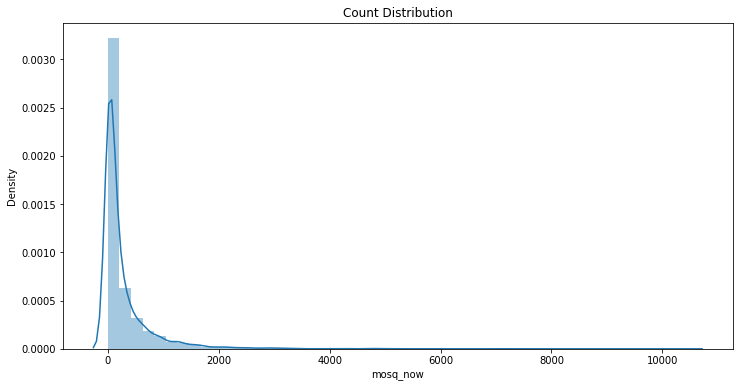

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [22]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

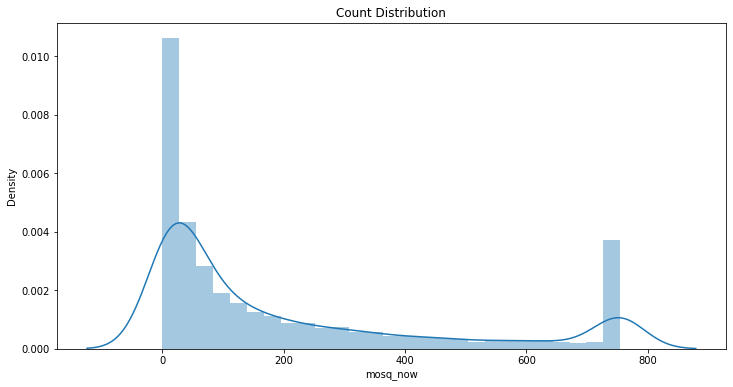

In [23]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

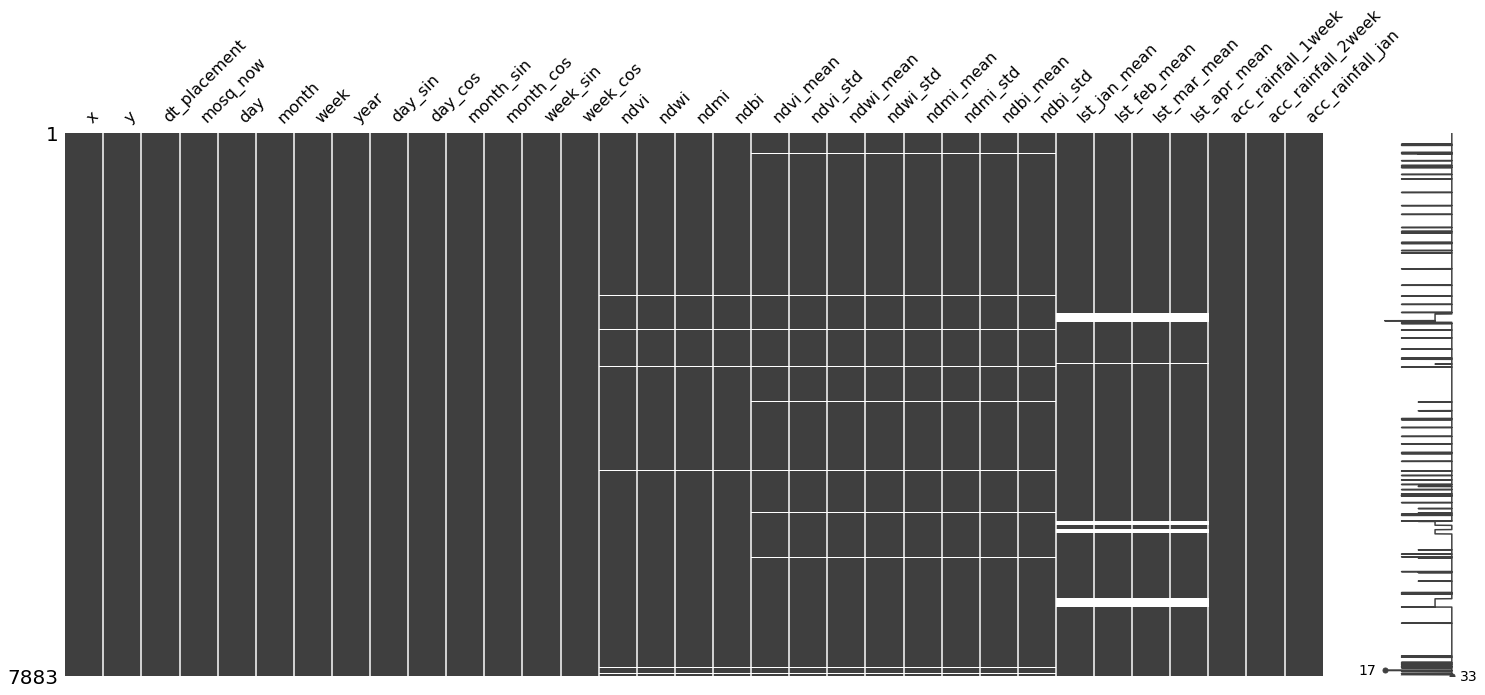

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                         'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [26]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

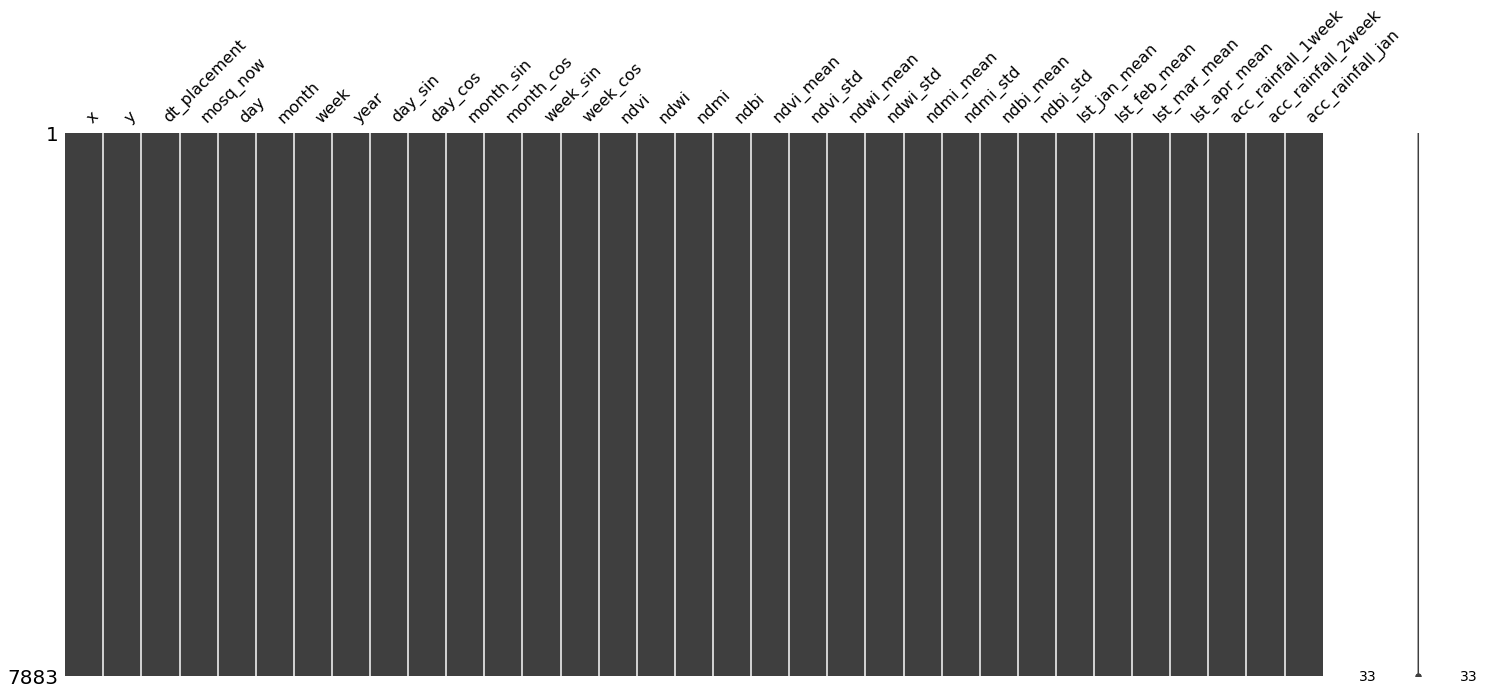

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [29]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [30]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.95154 | Val Loss: 24.68296 | Train Acc: 2.873| Val Acc: 2.673
Epoch 002: | Train Loss: 18.33261 | Val Loss: 27.53927 | Train Acc: 2.232| Val Acc: 2.228
Epoch 003: | Train Loss: 18.72068 | Val Loss: 24.44437 | Train Acc: 2.278| Val Acc: 1.943
Epoch 004: | Train Loss: 18.23632 | Val Loss: 24.85484 | Train Acc: 2.119| Val Acc: 1.982
Epoch 005: | Train Loss: 17.90281 | Val Loss: 24.64848 | Train Acc: 2.095| Val Acc: 1.958
Epoch 006: | Train Loss: 17.87523 | Val Loss: 23.57101 | Train Acc: 2.071| Val Acc: 1.957
Epoch 007: | Train Loss: 17.46281 | Val Loss: 23.65074 | Train Acc: 1.991| Val Acc: 1.962
Epoch 008: | Train Loss: 17.20520 | Val Loss: 23.79816 | Train Acc: 2.014| Val Acc: 2.013
Epoch 009: | Train Loss: 17.07122 | Val Loss: 23.22410 | Train Acc: 1.991| Val Acc: 2.054
Epoch 010: | Train Loss: 16.96327 | Val Loss: 23.83376 | Train Acc: 1.975| Val Acc: 1.990
Epoch 011: | Train Loss: 16.77570 | Val Loss: 23.69622 | Train Acc: 1.975| Val Acc: 2.065
Epoch 012:

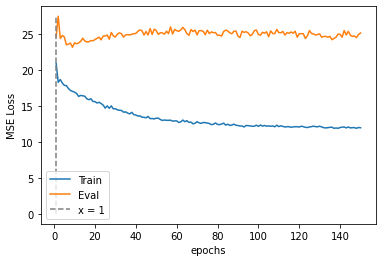

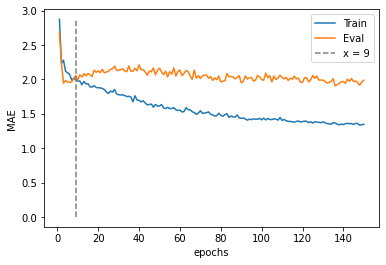

In [31]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
metrics(train, test, threshold=30)

MAE on train set:  143.0195385697779
min prediction: 1
max prediction: 973

MAE on test set:  159.17729056152297
Error ⩽ 30: 16.13 %
min prediction: 1
max prediction: 1024


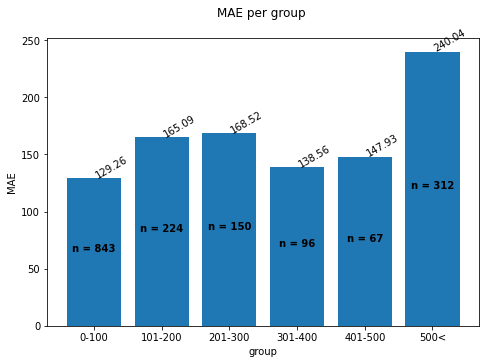

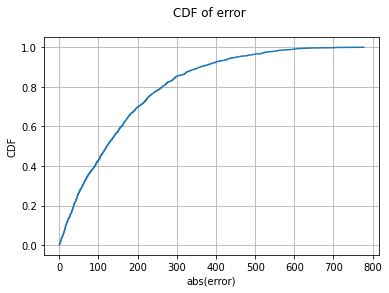

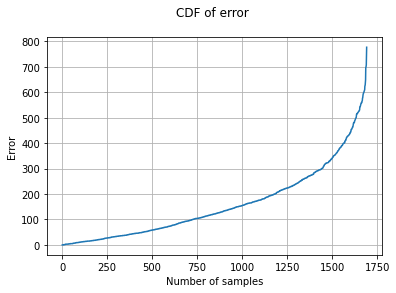

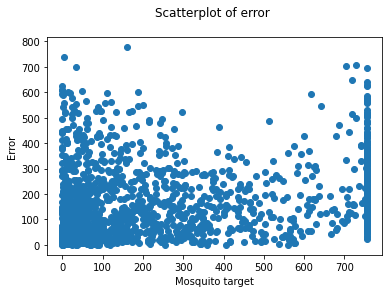

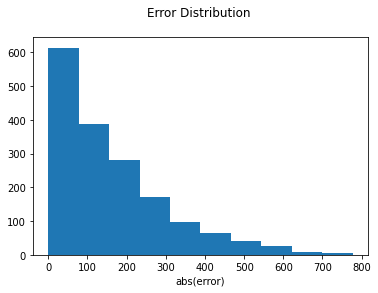

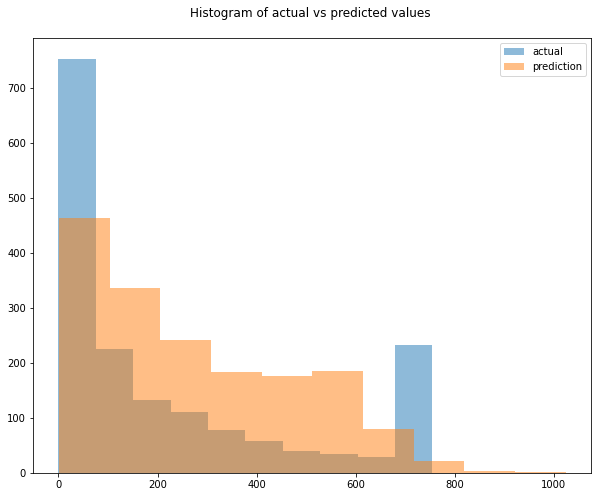

In [33]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 14.66326 | Val Loss: 4.64567 | Train Acc: 1.629| Val Acc: 2.633
Epoch 002: | Train Loss: 13.83482 | Val Loss: 4.66280 | Train Acc: 1.585| Val Acc: 2.633
Epoch 003: | Train Loss: 13.66831 | Val Loss: 4.92750 | Train Acc: 1.553| Val Acc: 2.633
Epoch 004: | Train Loss: 13.38999 | Val Loss: 6.13107 | Train Acc: 1.508| Val Acc: 2.633
Epoch 005: | Train Loss: 13.50569 | Val Loss: 5.80666 | Train Acc: 1.527| Val Acc: 2.633
Epoch 006: | Train Loss: 13.50143 | Val Loss: 4.55768 | Train Acc: 1.542| Val Acc: 2.633
Epoch 007: | Train Loss: 13.23587 | Val Loss: 4.42736 | Train Acc: 1.489| Val Acc: 1.633
Epoch 008: | Train Loss: 13.16827 | Val Loss: 4.34689 | Train Acc: 1.507| Val Acc: 1.633
Epoch 009: | Train Loss: 13.00185 | Val Loss: 6.66724 | Train Acc: 1.477| Val Acc: 2.633
Epoch 010: | Train Loss: 13.00945 | Val Loss: 5.95332 | Train Acc: 1.467| Val Acc: 2.633
Epoch 011: | Train Loss: 13.34282 | Val Loss: 4.53136 | Train Acc: 1.531| Val Acc: 1.633
Epoch 012: | Train Lo

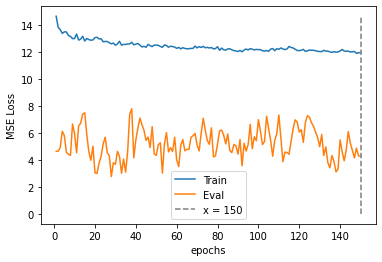

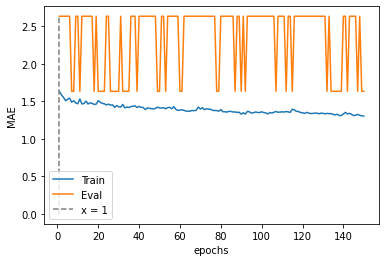

In [34]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [35]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [36]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [37]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [38]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [39]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [40]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

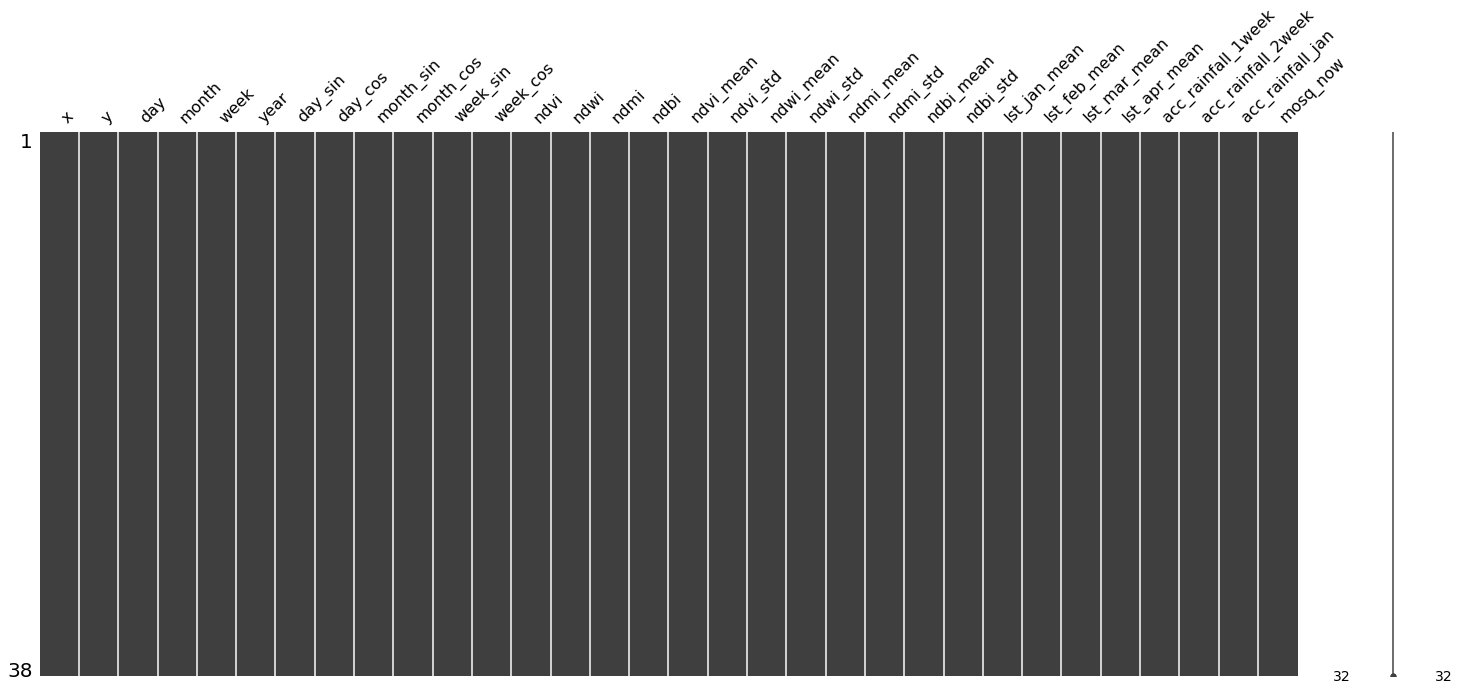

In [41]:
missingno.matrix(dataset_mamoth)

In [42]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [43]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [44]:
predictions = give_predictions(model, dataset_mamoth)

In [45]:
mosqutio_predictions['mosq_pred'] = predictions

In [46]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-08-01,45
1,21.940791,40.977027,2023-08-01,42
2,22.891980,40.656030,2023-08-01,112
3,23.982527,40.915102,2023-08-01,55
4,23.691080,40.495934,2023-08-01,46
...,...,...,...,...
33,23.828106,40.110264,2023-08-01,89
34,23.388058,41.313484,2023-08-01,55
35,22.146700,40.822940,2023-08-01,81
36,22.723020,40.753567,2023-08-01,111


In [47]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)